<a href="https://colab.research.google.com/github/neelay8975/NNDL_48_prac1/blob/main/Prac_7_48_nndlipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

implement an object detection model using cnn

problem statement :
in smart surviellence system, it is important  to automatically detect and identify objects such as people, cars,bicycle, animals from images . Mannual monitoring is time consuming and prone to human error

implement an object detection model using cnn

problem statement :
in smart surviellence system, it is important  to automatically detect and identify objects such as people, cars,bicycle, animals from images . Mannual monitoring is time consuming and prone to human error

develop an object detection model using cnn based pre trained ssd mobile net model in google colab to indentify and locate multiple objects present in an image

In [9]:
# Install TensorFlow Hub if not already installed
!pip install tensorflow_hub

```markdown
### Loading a Pre-trained SSD MobileNet Model from TensorFlow Hub

We will use a pre-trained SSD MobileNet V2 model from TensorFlow Hub. These models are already trained on large datasets (like COCO) and can detect a wide range of common objects.
```

In [10]:
import tensorflow_hub as hub

# URL for a pre-trained SSD MobileNet V2 model from TensorFlow Hub
# This model is trained on the COCO 2017 dataset.
model_handle = 'https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2'

print(f"Loading pre-trained SSD MobileNet V2 model from TensorFlow Hub: {model_handle}")

# Load the detection model
ssd_model = hub.load(model_handle)

print("Pre-trained SSD MobileNet V2 model loaded successfully!")

# The loaded model expects inputs in a specific format (usually batches of images).
# It returns dictionaries containing detection boxes, classes, scores, and number of detections.

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Loading pre-trained SSD MobileNet V2 model from TensorFlow Hub: https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2
Pre-trained SSD MobileNet V2 model loaded successfully!


```markdown
### Example of using the loaded SSD MobileNet model for inference

Here's how you can prepare an image and use the loaded `ssd_model` to make predictions. Remember that the output needs to be parsed to visualize the detections.
```

Running inference on /root/.keras/datasets/image1.jpg...
Number of detections: 100
Detection Scores (top 5): [0.7978461  0.41013038 0.32058507 0.28759074 0.27687678]
Detection Classes (top 5): ['cat', 'bear', 'bird', 'clock', 'skis']
Detection Boxes (top 5): [[0.07533771 0.21180555 0.93409127 0.9448104 ]
 [0.1552437  0.21818107 0.91863245 0.9146816 ]
 [0.5049841  0.7249142  0.72702557 0.95852745]
 [0.096921   0.211438   0.3897074  0.38618106]
 [0.90530556 0.33007517 0.9387178  0.48167244]]

Visualizing detections...


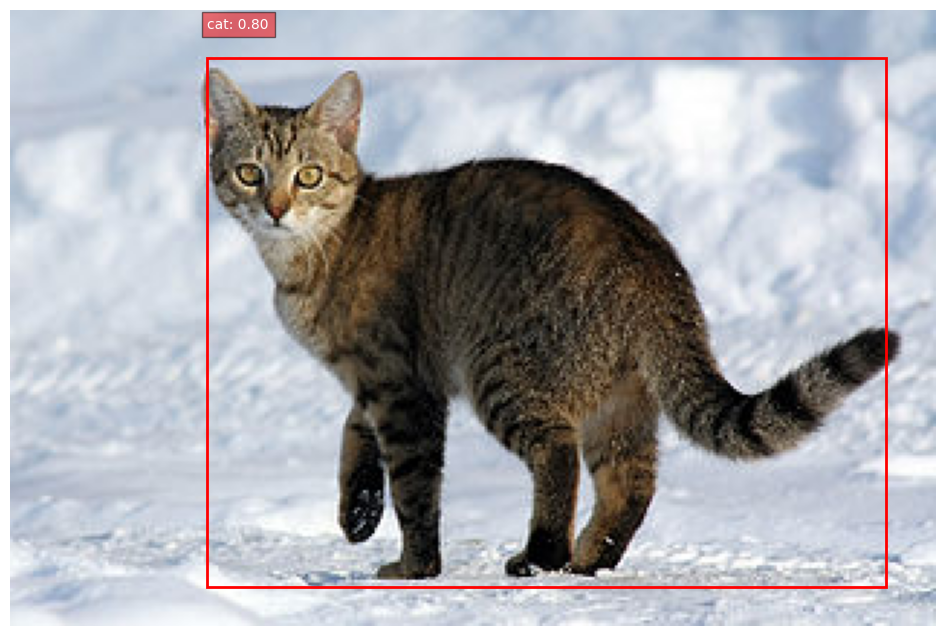

In [19]:
import tensorflow as tf
import numpy as np # Import numpy for array manipulation
import matplotlib.pyplot as plt # Import matplotlib for visualization
import PIL.Image

# COCO 2017 dataset class names (for the pre-trained SSD MobileNet V2 model)
# Index 0 is typically for background.
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Define the specific objects you want to detect and visualize
TARGET_OBJECTS = ['person', 'car', 'bicycle', 'cat', 'dog', 'bird', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe'] # Adding common animals

# Helper function to load and preprocess an image for the model
def load_image_for_ssd(image_path):
    # Load the image using tf.io.read_file
    img_raw = tf.io.read_file(image_path)

    # Decode the image, keeping it as uint8 (0-255 pixel values)
    img = tf.image.decode_jpeg(img_raw, channels=3)

    # The SSD MobileNet model from TF Hub expects uint8 unnormalized pixel values (0-255).
    # No tf.image.convert_image_dtype to float32 is needed here for this specific model.

    # Add a batch dimension (e.g., [height, width, channels] -> [1, height, width, channels])
    img = tf.expand_dims(img, axis=0)
    return img

# Placeholder for a sample image path
sample_image_path = tf.keras.utils.get_file(
    'image1.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg'
)

# Load and preprocess the sample image
input_image_tensor = load_image_for_ssd(sample_image_path)

# Make a prediction
print(f"Running inference on {sample_image_path}...")
results = ssd_model(input_image_tensor)

# The results dictionary contains:
# - detection_boxes: Bounding box coordinates in normalized [ymin, xmin, ymax, xmax] format.
# - detection_class_entities: Human-readable class names (NOT PRESENT in this model).
# - detection_class_labels: Integer class labels (PRESENT as 'detection_classes').
# - detection_scores: Confidence scores for each detection.
# - num_detections: The number of detections.

# Convert to numpy for easier printing and visualization after initial call
results_np = {key:value.numpy() for key,value in results.items()}

# You can print some results to see the format
print("Number of detections:", int(results_np['num_detections'][0]))
print("Detection Scores (top 5):", results_np['detection_scores'][0][:5])

# Get class names using the COCO_CLASSES list
top_5_class_ids = [int(class_id) for class_id in results_np['detection_classes'][0][:5]]
top_5_class_names = [COCO_CLASSES[class_id] for class_id in top_5_class_ids]
print("Detection Classes (top 5):", top_5_class_names)
print("Detection Boxes (top 5):", results_np['detection_boxes'][0][:5])


# --- Visualization part --- #
def visualize_detections(original_image_path, detections, threshold=0.3):
    # Load the image using PIL or matplotlib to display it
    image_np = np.array(PIL.Image.open(original_image_path))
    image_h, image_w, _ = image_np.shape

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_np)

    num_detections = int(detections['num_detections'][0])
    for i in range(num_detections):
        score = detections['detection_scores'][0][i]

        # Only visualize detections above a certain confidence threshold
        if score < threshold:
            continue

        bbox = detections['detection_boxes'][0][i] # [ymin, xmin, ymax, xmax]
        class_id = int(detections['detection_classes'][0][i]) # Get numerical class ID
        label = COCO_CLASSES[class_id] # Map to human-readable label

        # Filter by desired objects
        if label not in TARGET_OBJECTS:
            continue

        ymin, xmin, ymax, xmax = bbox

        # Convert normalized coordinates to pixel coordinates
        xmin_pixel = xmin * image_w
        xmax_pixel = xmax * image_w
        ymin_pixel = ymin * image_h
        ymax_pixel = ymax * image_h

        # Create a Rectangle patch for the bounding box
        rect = plt.Rectangle((xmin_pixel, ymin_pixel), xmax_pixel - xmin_pixel, ymax_pixel - ymin_pixel,
                             fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)

        # Add the label and score text
        ax.text(xmin_pixel, ymin_pixel - 10, f'{label}: {score:.2f}',
                bbox=dict(facecolor='red', alpha=0.5), fontsize=10, color='white')

    plt.axis('off')
    plt.show()

print("\nVisualizing detections...")
visualize_detections(sample_image_path, results_np, threshold=0.5)


```markdown
### Test with Your Own Image

Now, let's try running the object detection on an image you upload. Make sure to upload an image containing objects like humans, cars, bicycles, or animals for the model to detect.
```

Saving sample.jpg to sample (5).jpg
Uploaded file: sample (5).jpg
Processing uploaded image: /tmp/sample (5).jpg

Visualizing detections on uploaded image...


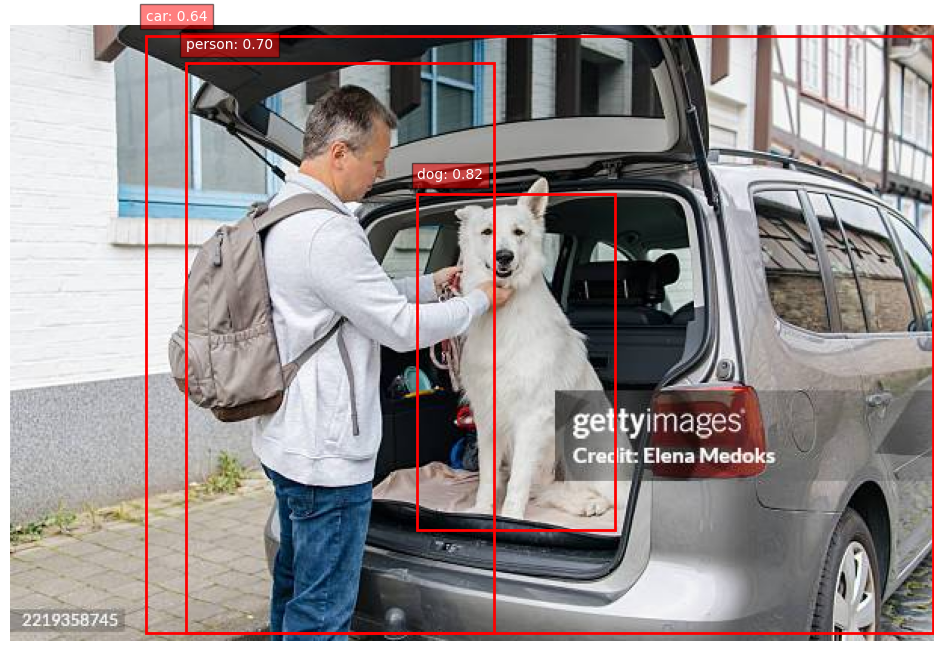

In [22]:
from google.colab import files
import io
import os

uploaded = files.upload()

# Assuming only one file is uploaded
for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')
    # Save the uploaded file to a temporary path
    uploaded_image_path = os.path.join('/tmp', filename)
    with open(uploaded_image_path, 'wb') as f:
        f.write(uploaded[filename])

    print(f"Processing uploaded image: {uploaded_image_path}")

    # Load and preprocess the uploaded image
    input_image_tensor_uploaded = load_image_for_ssd(uploaded_image_path)

    # Make a prediction
    results_uploaded = ssd_model(input_image_tensor_uploaded)
    results_uploaded_np = {key:value.numpy() for key,value in results_uploaded.items()}

    # Visualize detections on the uploaded image with the new filtering
    print("\nVisualizing detections on uploaded image...")
    visualize_detections(uploaded_image_path, results_uploaded_np, threshold=0.5)

    # You can also print the raw results for the uploaded image if needed
    # print("Number of detections:", int(results_uploaded_np['num_detections'][0]))
    # print("Detection Scores (top 5):", results_uploaded_np['detection_scores'][0][:5])
    # top_5_class_ids_uploaded = [int(class_id) for class_id in results_uploaded_np['detection_classes'][0][:5]]
    # top_5_class_names_uploaded = [COCO_CLASSES[class_id] for class_id in top_5_class_ids_uploaded]
    # print("Detection Classes (top 5):", top_5_class_names_uploaded)
    # print("Detection Boxes (top 5):", results_uploaded_np['detection_boxes'][0][:5])
